In [ ]:
import os

# --- Local paths: set these env vars, or edit the fallback strings ---
PROJECT_DIR = os.environ.get("PA_FLOOD_PROJECT", r"C:\path\to\PA Flood Risk GIS")
DATA_DIR    = os.environ.get("PA_FLOOD_DATA",    r"C:\path\to\Final Project\Data")

PROJECT_GDB = os.path.join(PROJECT_DIR, "PA Flood Risk GIS.gdb")
OUTPUT_DIR  = PROJECT_DIR


In [1]:
import pandas as pd
import geopandas as gpd

import time

# OSMnx is the library you used to pull OpenStreetMap (OSM) features
import osmnx as ox

print("OSMnx version:", ox.__version__)

OSMnx version: 2.1.0


In [2]:
# Optional: keep Overpass requests polite and reduce throttling risk
ox.settings.overpass_rate_limit = True
ox.settings.requests_timeout = 180

# Pennsylvania counties (67)
county_name_list = [
    "Adams County, Pennsylvania, USA",
    "Allegheny County, Pennsylvania, USA",
    "Armstrong County, Pennsylvania, USA",
    "Beaver County, Pennsylvania, USA",
    "Bedford County, Pennsylvania, USA",
    "Berks County, Pennsylvania, USA",
    "Blair County, Pennsylvania, USA",
    "Bradford County, Pennsylvania, USA",
    "Bucks County, Pennsylvania, USA",
    "Butler County, Pennsylvania, USA",
    "Cambria County, Pennsylvania, USA",
    "Cameron County, Pennsylvania, USA",
    "Carbon County, Pennsylvania, USA",
    "Centre County, Pennsylvania, USA",
    "Chester County, Pennsylvania, USA",
    "Clarion County, Pennsylvania, USA",
    "Clearfield County, Pennsylvania, USA",
    "Clinton County, Pennsylvania, USA",
    "Columbia County, Pennsylvania, USA",
    "Crawford County, Pennsylvania, USA",
    "Cumberland County, Pennsylvania, USA",
    "Dauphin County, Pennsylvania, USA",
    "Delaware County, Pennsylvania, USA",
    "Elk County, Pennsylvania, USA",
    "Erie County, Pennsylvania, USA",
    "Fayette County, Pennsylvania, USA",
    "Forest County, Pennsylvania, USA",
    "Franklin County, Pennsylvania, USA",
    "Fulton County, Pennsylvania, USA",
    "Greene County, Pennsylvania, USA",
    "Huntingdon County, Pennsylvania, USA",
    "Indiana County, Pennsylvania, USA",
    "Jefferson County, Pennsylvania, USA",
    "Juniata County, Pennsylvania, USA",
    "Lackawanna County, Pennsylvania, USA",
    "Lancaster County, Pennsylvania, USA",
    "Lawrence County, Pennsylvania, USA",
    "Lebanon County, Pennsylvania, USA",
    "Lehigh County, Pennsylvania, USA",
    "Luzerne County, Pennsylvania, USA",
    "Lycoming County, Pennsylvania, USA",
    "McKean County, Pennsylvania, USA",
    "Mercer County, Pennsylvania, USA",
    "Mifflin County, Pennsylvania, USA",
    "Monroe County, Pennsylvania, USA",
    "Montgomery County, Pennsylvania, USA",
    "Montour County, Pennsylvania, USA",
    "Northampton County, Pennsylvania, USA",
    "Northumberland County, Pennsylvania, USA",
    "Perry County, Pennsylvania, USA",
    "Philadelphia County, Pennsylvania, USA",
    "Pike County, Pennsylvania, USA",
    "Potter County, Pennsylvania, USA",
    "Schuylkill County, Pennsylvania, USA",
    "Snyder County, Pennsylvania, USA",
    "Somerset County, Pennsylvania, USA",
    "Sullivan County, Pennsylvania, USA",
    "Susquehanna County, Pennsylvania, USA",
    "Tioga County, Pennsylvania, USA",
    "Union County, Pennsylvania, USA",
    "Venango County, Pennsylvania, USA",
    "Warren County, Pennsylvania, USA",
    "Washington County, Pennsylvania, USA",
    "Wayne County, Pennsylvania, USA",
    "Westmoreland County, Pennsylvania, USA",
    "Wyoming County, Pennsylvania, USA",
    "York County, Pennsylvania, USA",
]

print("Counties:", len(county_name_list))

Counties: 67


In [3]:
# Tags to pull from OpenStreetMap
tags = {"power": "substation"}

substation_gdf_list = []
failed_county_list = []

for idx, county_name in enumerate(county_name_list, start=1):
    try:
        print(f"[{idx:02d}/67] Downloading: {county_name}")
        county_gdf = ox.features_from_place(county_name, tags=tags)

        # Ensure GeoDataFrame
        if not isinstance(county_gdf, gpd.GeoDataFrame) or county_gdf.empty:
            print(f"  No substations found.")
            continue

        county_gdf = county_gdf.reset_index()

        # Keep a county label for traceability
        county_gdf["county_name"] = county_name

        substation_gdf_list.append(county_gdf)

        # Be gentle with Overpass
        time.sleep(1)

    except Exception as e:
        print(f"  FAILED: {county_name} | {type(e).__name__}: {e}")
        failed_county_list.append({"county_name": county_name, "error": str(e)})

print("\nCompleted.")
print("County results:")
print("  Successful counties:", len(substation_gdf_list))
print("  Failed counties:", len(failed_county_list))

# Combine
if len(substation_gdf_list) == 0:
    raise RuntimeError("No substation data were downloaded. Check internet access / Overpass settings.")

substations_raw_gdf = pd.concat(substation_gdf_list, ignore_index=True)
substations_raw_gdf = gpd.GeoDataFrame(substations_raw_gdf, geometry="geometry", crs="EPSG:4326")

print("Raw substation rows:", len(substations_raw_gdf))
substations_raw_gdf.head(3)


[01/67] Downloading: Adams County, Pennsylvania, USA
[02/67] Downloading: Allegheny County, Pennsylvania, USA
[03/67] Downloading: Armstrong County, Pennsylvania, USA
[04/67] Downloading: Beaver County, Pennsylvania, USA
[05/67] Downloading: Bedford County, Pennsylvania, USA
[06/67] Downloading: Berks County, Pennsylvania, USA
[07/67] Downloading: Blair County, Pennsylvania, USA
[08/67] Downloading: Bradford County, Pennsylvania, USA
[09/67] Downloading: Bucks County, Pennsylvania, USA
[10/67] Downloading: Butler County, Pennsylvania, USA
[11/67] Downloading: Cambria County, Pennsylvania, USA
[12/67] Downloading: Cameron County, Pennsylvania, USA
[13/67] Downloading: Carbon County, Pennsylvania, USA
[14/67] Downloading: Centre County, Pennsylvania, USA
[15/67] Downloading: Chester County, Pennsylvania, USA
[16/67] Downloading: Clarion County, Pennsylvania, USA
[17/67] Downloading: Clearfield County, Pennsylvania, USA
[18/67] Downloading: Clinton County, Pennsylvania, USA
[19/67] Downlo

,element,id,geometry,barrier,check_date,fence_type,name,not:operator:wikidata,note,operator,...,material,ele,gnis:feature_id,industrial,designation,operator:website,name:es,status,start_date,addr:unit
0,relation,17027648,"MULTIPOLYGON (((-77.20108 40.00751, -77.20101 ...",fence,2022-05-10,chain_link,Gardners Substation,Q1419248,Reference the map on page 3 for information. C...,Metropolitan Edison,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,way,99714143,"POLYGON ((-77.12637 39.75886, -77.12548 39.758...",fence,2022-01-20,chain_link,Germantown Substation,Q1419248,Reference the map on page 2 for information. S...,Met-Ed,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,way,106954554,"POLYGON ((-77.07567 39.85536, -77.07534 39.855...",fence,2022-07-21,chain_link,Oxford Substation,Q1419248,Reference the map on page 9 for information.,Metropolitan Edison,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# --- Ensure geometry is valid ---
substations_raw_gdf = substations_raw_gdf[substations_raw_gdf.geometry.notnull()].copy()
substations_raw_gdf = substations_raw_gdf[~substations_raw_gdf.geometry.is_empty]

print("After removing null geometries:", len(substations_raw_gdf))

# --- Convert polygons/multipolygons to centroid points ---
substations_raw_gdf["geometry"] = substations_raw_gdf.geometry.centroid

print("Converted to centroid points.")

# --- Remove duplicate substations using OSM ID ---
before_dedup = len(substations_raw_gdf)

substations_clean_gdf = substations_raw_gdf.drop_duplicates(subset=["id"]).copy()

after_dedup = len(substations_clean_gdf)

print("Before dedup:", before_dedup)
print("After dedup:", after_dedup)
print("Duplicates removed:", before_dedup - after_dedup)

substations_clean_gdf.head(3)


<class 'NameError'>: name 'substations_raw_gdf' is not defined

In [5]:
# Start from polygon geometry again
substations_poly_gdf = substations_raw_gdf.copy()

substations_poly_gdf = substations_poly_gdf[substations_poly_gdf.geometry.notnull()].copy()
substations_poly_gdf = substations_poly_gdf[~substations_poly_gdf.geometry.is_empty]

# Ensure CRS defined
substations_poly_gdf = substations_poly_gdf.set_crs("EPSG:4326", allow_override=True)

# Temporary projection for centroid math (StatePlane South)
substations_temp_2272 = substations_poly_gdf.to_crs("EPSG:2272")

# Compute centroids correctly
substations_temp_2272["geometry"] = substations_temp_2272.geometry.centroid

# Convert back to FEMA CRS (EPSG:4269)
substations_clean_gdf = substations_temp_2272.to_crs("EPSG:4269")

# Deduplicate
before_dedup = len(substations_clean_gdf)
substations_clean_gdf = substations_clean_gdf.drop_duplicates(subset=["id"]).copy()
after_dedup = len(substations_clean_gdf)

print("Final rows:", after_dedup)
print("Duplicates removed:", before_dedup - after_dedup)


Final rows: 2333
Duplicates removed: 3


In [5]:
# Pick columns that usually exist in OSMnx outputs; keep only those that are present
candidate_column_list = [
    "element", "id", "county_name",
    "name", "operator", "voltage", "substation",
    "ref", "source", "note"
]

existing_column_list = [c for c in candidate_column_list if c in substations_clean_gdf.columns]

substations_final_gdf = substations_clean_gdf[existing_column_list + ["geometry"]].copy()

# Add a stable unique key for joins/logging
substations_final_gdf["osm_uid"] = (
    substations_clean_gdf["element"].astype(str) + "_" + substations_clean_gdf["id"].astype(str)
)

# Confirm CRS matches FEMA (EPSG:4269)
print("CRS:", substations_final_gdf.crs)
print("Columns:", list(substations_final_gdf.columns))
print("Rows:", len(substations_final_gdf))

substations_final_gdf.head(3)


<class 'NameError'>: name 'substations_clean_gdf' is not defined

In [7]:
output_gpkg_path = os.path.join(DATA_DIR, "OSM_PA", "PA_substations_statewide_clean.gpkg")
layer_name = "PA_substations_statewide_clean"

# Write GeoPackage
substations_final_gdf.to_file(output_gpkg_path, layer=layer_name, driver="GPKG")

print("Wrote:", output_gpkg_path)


Wrote: C:\Users\Owner\Downloads\Geospatial Data Science\Final Project\Data\OSM_PA\PA_substations_statewide_clean.gpkg


In [7]:
import arcpy

# workspace
arcpy.env.workspace = PROJECT_GDB
arcpy.env.overwriteOutput = True

# input layers
gage_in = "S_GAGE"
subbasin_in = "S_SUBBASINS"
water_in = "S_WTR_AR"

# outputs
gage_out = "S_GAGE_2272"
subbasin_out = "S_SUBBASINS_2272"
water_out = "S_WTR_AR_2272"

# target coordinate system
sr = arcpy.SpatialReference(2272)

# project layers
arcpy.management.Project(gage_in, gage_out, sr)
arcpy.management.Project(subbasin_in, subbasin_out, sr)
arcpy.management.Project(water_in, water_out, sr)

print("Projection complete.")

Projection complete.


In [8]:
arcpy.env.workspace = PROJECT_GDB
arcpy.env.overwriteOutput = True

substations = "PA_substations_statewide_clean_2272"
gages = "S_GAGE_2272"

arcpy.analysis.Near(
    in_features=substations,
    near_features=gages,
    location="LOCATION",
    angle="NO_ANGLE",
    method="PLANAR"
)

print("Nearest gage assigned to each substation.")

Nearest gage assigned to each substation.


In [9]:
arcpy.management.JoinField(
    in_data="PA_substations_statewide_clean_2272",
    in_field="NEAR_FID",
    join_table="S_GAGE_2272",
    join_field="OBJECTID",
    fields=["GAGE_OWNID","WTR_NM","GAGE_DESC"]
)

<Result 'PA_substations_statewide_clean_2272'>

In [10]:
import pandas as pd
import requests
import io

gage_ids = []

with arcpy.da.SearchCursor(
        "PA_substations_statewide_clean_2272",
        ["GAGE_OWNID"]) as cursor:

    for row in cursor:
        g = row[0].replace("USGS ","")
        gage_ids.append(g)

gage_ids = list(set(gage_ids))

all_peaks = []

for site in gage_ids:

    url = f"https://nwis.waterdata.usgs.gov/nwis/peak?site_no={site}&format=rdb"

    try:

        r = requests.get(url)

        if r.status_code != 200:
            continue

        lines = [
            l for l in r.text.split("\n")
            if not l.startswith("#")
        ]

        df = pd.read_csv(
            io.StringIO("\n".join(lines)),
            sep="\t"
        )

        df["site_no"] = site

        all_peaks.append(df)

    except:
        continue


peak_data = pd.concat(all_peaks)

print("Records downloaded:", len(peak_data))

Records downloaded: 1909


In [11]:
peak_data.columns

Index(['agency_cd', 'site_no', 'peak_dt', 'peak_tm', 'peak_va', 'peak_cd',
       'gage_ht', 'gage_ht_cd', 'year_last_pk', 'ag_dt', 'ag_tm', 'ag_gage_ht',
       'ag_gage_ht_cd'],
      dtype='object')

In [12]:
peak_data["peak_va"] = pd.to_numeric(peak_data["peak_va"], errors="coerce")
peak_data["gage_ht"] = pd.to_numeric(peak_data["gage_ht"], errors="coerce")

peak_data["peak_dt"] = pd.to_datetime(
    peak_data["peak_dt"],
    format="%Y-%m-%d",
    errors="coerce"
)

In [13]:
peak_data["peak_dt"].isna().sum()

np.int64(30)

In [14]:
peak_data["peak_dt"].min(), peak_data["peak_dt"].max()

(Timestamp('1786-10-05 00:00:00'), Timestamp('2025-07-10 00:00:00'))

In [15]:
peak_data[["peak_va","gage_ht"]].dtypes

peak_va    float64
gage_ht    float64
dtype: object

In [16]:
import numpy as np

flood_analysis = peak_data.copy()

flood_analysis = flood_analysis.dropna(subset=["peak_va"])

flood_analysis = flood_analysis.sort_values(
    ["site_no","peak_va"],
    ascending=[True, False]
)

flood_analysis["rank"] = flood_analysis.groupby("site_no")["peak_va"]\
                                       .rank(method="first", ascending=False)

flood_analysis["n_obs"] = flood_analysis.groupby("site_no")["peak_va"]\
                                        .transform("count")

flood_analysis["exceedance_probability"] = (
    flood_analysis["rank"] / (flood_analysis["n_obs"] + 1)
)

flood_analysis["return_period"] = 1 / flood_analysis["exceedance_probability"]

In [17]:
flood_analysis.head(10)

,agency_cd,site_no,peak_dt,peak_tm,peak_va,peak_cd,gage_ht,gage_ht_cd,year_last_pk,ag_dt,ag_tm,ag_gage_ht,ag_gage_ht_cd,rank,n_obs,exceedance_probability,return_period
10,USGS,01468500,1972-06-22,NaN,14000.0,7,17.36,NaN,NaN,NaN,NaN,NaN,NaN,1.0,60,0.016393,61.000000
43,USGS,01468500,2006-06-28,NaN,13300.0,NaN,17.20,NaN,NaN,NaN,NaN,NaN,NaN,2.0,60,0.032787,30.500000
55,USGS,01468500,2018-08-13,15:07,9340.0,NaN,15.29,NaN,NaN,NaN,NaN,NaN,NaN,3.0,60,0.049180,20.333333
5,USGS,01468500,1950-11-25,NaN,8570.0,NaN,13.29,NaN,NaN,NaN,NaN,NaN,NaN,4.0,60,0.065574,15.250000
48,USGS,01468500,2011-09-08,NaN,7360.0,NaN,14.11,NaN,NaN,NaN,NaN,NaN,NaN,5.0,60,0.081967,12.200000
31,USGS,01468500,1993-11-28,NaN,6820.0,NaN,13.36,NaN,NaN,NaN,NaN,NaN,NaN,6.0,60,0.098361,10.166667
33,USGS,01468500,1996-01-27,NaN,6410.0,NaN,12.91,NaN,NaN,NaN,NaN,NaN,NaN,7.0,60,0.114754,8.714286
58,USGS,01468500,2021-09-01,22:45,6330.0,NaN,13.39,NaN,NaN,NaN,NaN,NaN,NaN,8.0,60,0.131148,7.625000
41,USGS,01468500,2004-09-18,NaN,6000.0,NaN,13.85,NaN,NaN,NaN,NaN,NaN,NaN,9.0,60,0.147541,6.777778
20,USGS,01468500,1983-04-16,NaN,5870.0,NaN,13.60,NaN,NaN,NaN,NaN,NaN,NaN,10.0,60,0.163934,6.100000


In [18]:
flood_analysis.groupby("site_no")["n_obs"].first().describe()

count     27.000000
mean      69.592593
std       37.102000
min       13.000000
25%       38.500000
50%       60.000000
75%      100.500000
max      139.000000
Name: n_obs, dtype: float64

In [19]:
def estimate_q100(df):

    df = df.sort_values("return_period")

    return np.interp(
        100,
        df["return_period"],
        df["peak_va"]
    )

q100_estimates = (
    flood_analysis
    .groupby("site_no")
    .apply(estimate_q100)
    .reset_index()
)

q100_estimates.columns = ["site_no","q100_cfs"]

q100_estimates.head()

C:/Users/Owner/AppData/Local/Temp/ArcGISProTemp23148/xpython_23148/3873069271.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_q100)


,site_no,q100_cfs
0,01468500,14000.000000
1,01469500,7474.150943
2,01470779,7800.000000
3,01515000,167000.000000
4,01530332,235000.000000


In [20]:
def estimate_stage100(df):

    df = df.sort_values("peak_va")

    q100 = np.interp(
        100,
        df["return_period"],
        df["peak_va"]
    )

    stage100 = np.interp(
        q100,
        df["peak_va"],
        df["gage_ht"]
    )

    return stage100


stage100_estimates = (
    flood_analysis
    .groupby("site_no")
    .apply(estimate_stage100)
    .reset_index()
)

stage100_estimates.columns = ["site_no","stage100_ft"]

stage100_estimates.head()

C:/Users/Owner/AppData/Local/Temp/ArcGISProTemp23148/xpython_23148/618072777.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(estimate_stage100)


,site_no,stage100_ft
0,01468500,17.360000
1,01469500,10.692453
2,01470779,11.510000
3,01515000,26.670000
4,01530332,NaN


In [29]:
flood_analysis.groupby("site_no")["gage_ht"].apply(lambda x: x.notna().sum()).sort_values()

site_no
01573695     13
01574800     16
01538800     21
01577500     26
01573160     31
01572190     36
01572025     37
01530332     37
01533400     49
01537000     50
01573560     50
01470779     52
01568500     56
01468500     60
01575000     67
01571500     81
01575500     87
01515000     90
01574500     95
01574000     96
01538000    105
01469500    105
01573000    107
01534000    108
01531000    122
01531500    133
01536500    134
Name: gage_ht, dtype: int64

In [30]:
type(substations)

pandas.core.frame.DataFrame

In [31]:
feature_class = "PA_substations_statewide_clean_2272"

fields = ["GAGE_OWNID"]

rows = []

with arcpy.da.SearchCursor(feature_class, fields) as cursor:
    for row in cursor:
        rows.append(row)

substations = pd.DataFrame(rows, columns=fields)

In [32]:
type(substations)

pandas.core.frame.DataFrame

In [33]:
substations["site_no"] = substations["GAGE_OWNID"].str.replace("USGS ", "", regex=False)

In [34]:
substation_flood = substations.merge(
    q100_estimates,
    on="site_no",
    how="left"
)

substation_flood = substation_flood.merge(
    stage100_estimates,
    on="site_no",
    how="left"
)

In [35]:
substation_flood.head()

,GAGE_OWNID,site_no,q100_cfs,stage100_ft
0,USGS 01574500,01574500,19400.0,15.57
1,USGS 01574500,01574500,19400.0,15.57
2,USGS 01574500,01574500,19400.0,15.57
3,USGS 01574500,01574500,19400.0,15.57
4,USGS 01574500,01574500,19400.0,15.57


In [36]:
summary_stats = substation_flood[[
    "q100_cfs",
    "stage100_ft"
]].describe()

summary_stats

,q100_cfs,stage100_ft
count,895.000000,768.000000
mean,86697.301898,18.986023
std,113045.280177,10.381461
min,1280.000000,6.070000
25%,7474.150943,10.692453
50%,19300.000000,15.570000
75%,235000.000000,22.620000
max,325000.000000,44.480000


In [37]:
summary_table = summary_stats.round(2)

summary_table

,q100_cfs,stage100_ft
count,895.00,768.00
mean,86697.30,18.99
std,113045.28,10.38
min,1280.00,6.07
25%,7474.15,10.69
50%,19300.00,15.57
75%,235000.00,22.62
max,325000.00,44.48


In [38]:
gage_summary = substation_flood.drop_duplicates("site_no")[[
    "q100_cfs",
    "stage100_ft"
]].describe().round(2)

gage_summary

,q100_cfs,stage100_ft
count,27.00,26.00
mean,74616.21,20.72
std,101055.15,9.80
min,1280.00,6.07
25%,6399.06,12.12
50%,23100.00,19.63
75%,96550.00,26.36
max,325000.00,44.48


In [39]:
gage_infrastructure = (
    substation_flood
    .groupby(["site_no","q100_cfs","stage100_ft"])
    .size()
    .reset_index(name="n_substations")
)

gage_infrastructure = gage_infrastructure.sort_values(
    "n_substations",
    ascending=False
)

gage_infrastructure.head(10)

,site_no,q100_cfs,stage100_ft,n_substations
1,01469500,7474.150943,10.692453,171
2,01470779,7800.000000,11.510000,60
8,01536500,325000.000000,41.910000,60
7,01534000,38954.545455,20.680000,57
13,01571500,19300.000000,18.770000,47
21,01574500,19400.000000,15.570000,45
19,01573695,3580.000000,10.210000,39
0,01468500,14000.000000,17.360000,33
25,01577500,18000.000000,20.500000,29
5,01531500,284477.611940,31.953284,25


In [40]:
susquehanna_candidates = gage_infrastructure.sort_values(
    "q100_cfs",
    ascending=False
)

susquehanna_candidates.head(5)

,site_no,q100_cfs,stage100_ft,n_substations
8,01536500,325000.000000,41.910000,60
6,01533400,293000.000000,44.480000,21
5,01531500,284477.611940,31.953284,25
4,01531000,167682.926829,28.759024,10
3,01515000,167000.000000,26.670000,3


In [41]:
susquehanna_summary = gage_infrastructure[
    gage_infrastructure["q100_cfs"] > 150000
]

susquehanna_summary

,site_no,q100_cfs,stage100_ft,n_substations
8,01536500,325000.000000,41.910000,60
5,01531500,284477.611940,31.953284,25
6,01533400,293000.000000,44.480000,21
4,01531000,167682.926829,28.759024,10
3,01515000,167000.000000,26.670000,3


In [42]:
report_table = gage_infrastructure[
    ["site_no","n_substations","q100_cfs","stage100_ft"]
].sort_values(
    "n_substations",
    ascending=False
)

report_table

,site_no,n_substations,q100_cfs,stage100_ft
1,01469500,171,7474.150943,10.692453
2,01470779,60,7800.000000,11.510000
8,01536500,60,325000.000000,41.910000
7,01534000,57,38954.545455,20.680000
13,01571500,47,19300.000000,18.770000
21,01574500,45,19400.000000,15.570000
19,01573695,39,3580.000000,10.210000
0,01468500,33,14000.000000,17.360000
25,01577500,29,18000.000000,20.500000
5,01531500,25,284477.611940,31.953284


In [43]:
substation_flood.groupby("site_no").size().sort_values(ascending=False)

site_no
USGS_01567500    949
USGS             468
01469500         171
01530332         127
01470779          60
01536500          60
01534000          57
01571500          47
01574500          45
01573695          39
01468500          33
01577500          29
01531500          25
01537000          25
01574000          25
01575500          23
USGS_01568000     21
01533400          21
01573560          18
01538000          16
01573160          15
01572025          12
01574800          10
01531000          10
01538800           8
01568500           6
01575000           4
01515000           3
01572190           3
01573000           3
dtype: int64

In [44]:
substation_flood[substation_flood["site_no"].str.contains("USGS", na=False)]

,GAGE_OWNID,site_no,q100_cfs,stage100_ft
26,USGS_01567500,USGS_01567500,NaN,NaN
27,USGS_01567500,USGS_01567500,NaN,NaN
28,USGS_01567500,USGS_01567500,NaN,NaN
29,USGS_01567500,USGS_01567500,NaN,NaN
30,USGS_01567500,USGS_01567500,NaN,NaN
...,...,...,...,...
2242,USGS_01567500,USGS_01567500,NaN,NaN
2243,USGS_01567500,USGS_01567500,NaN,NaN
2244,USGS_01567500,USGS_01567500,NaN,NaN
2245,USGS_01567500,USGS_01567500,NaN,NaN


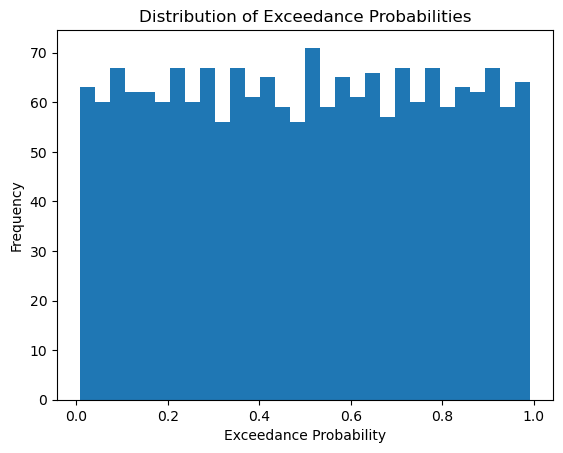

In [46]:
# exceedence probability dist
import matplotlib.pyplot as plt

plt.figure()
plt.hist(flood_analysis["exceedance_probability"].dropna(), bins=30)
plt.xlabel("Exceedance Probability")
plt.ylabel("Frequency")
plt.title("Distribution of Exceedance Probabilities")
plt.show()

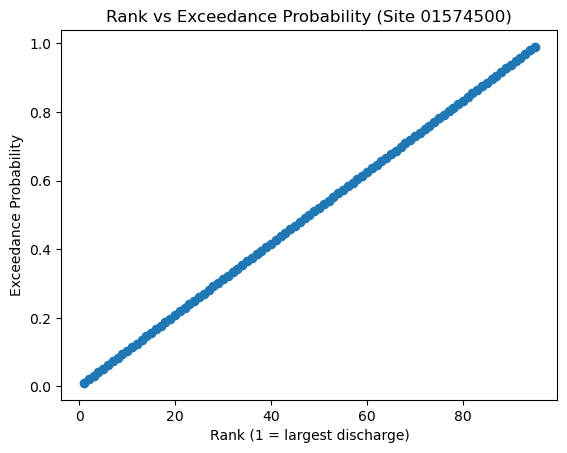

In [47]:
#one gage exceedence probability
site_example = "01574500"  # replace with your Susquehanna site if needed

df_site = flood_analysis[flood_analysis["site_no"] == site_example].copy()

plt.figure()
plt.scatter(df_site["rank"], df_site["exceedance_probability"])

plt.xlabel("Rank (1 = largest discharge)")
plt.ylabel("Exceedance Probability")
plt.title(f"Rank vs Exceedance Probability (Site {site_example})")

plt.show()

### Repulling Gages

In [1]:
import requests
import pandas as pd
import io

# USGS site service URL
url = "https://waterservices.usgs.gov/nwis/site/"

params = {
    "format": "rdb",
    "stateCd": "PA",
    "siteType": "ST"  # stream gages only
}

response = requests.get(url, params=params)

# Parse response (skip comment lines)
lines = [
    line for line in response.text.split("\n")
    if not line.startswith("#")
]

gages_df = pd.read_csv(
    io.StringIO("\n".join(lines)),
    sep="\t"
)

print("Total gages pulled:", len(gages_df))
gages_df.head()

Total gages pulled: 5689


,agency_cd,site_no,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,alt_va,alt_acy_va,alt_datum_cd,huc_cd
0,5s,15s,50s,7s,16s,16s,1s,10s,8s,3s,10s,16s
1,USGS,0142665005,FAUIKNER BROOK AT MOUTH AT BALLS EDDY PA,ST,41.98147427,-75.33961828,S,NAD83,NaN,NaN,NaN,02040101
2,USGS,01426690,"Faulkner Brook near Balls Eddy, PA",ST,41.9835,-75.34325,S,NAD83,996,2.0,NAVD88,02040101
3,USGS,01426700,BALLS CREEK NEAR WINTERDALE PA,ST,41.96814105,-75.3360073,S,NAD83,NaN,NaN,NaN,02040101
4,USGS,0142670005,BALLS CREEK AT MOUTH AT BALLS EDDY PA,ST,41.9700855,-75.3348961,S,NAD83,NaN,NaN,NaN,02040101


In [3]:
# Remove the USGS RDB format row and coerce coordinates to numeric

gages_df = gages_df.copy()

# Drop rows where latitude/longitude are not numeric
gages_df["dec_lat_va"] = pd.to_numeric(gages_df["dec_lat_va"], errors="coerce")
gages_df["dec_long_va"] = pd.to_numeric(gages_df["dec_long_va"], errors="coerce")

# Keep only rows with valid coordinates
gages_df = gages_df.dropna(subset=["dec_lat_va", "dec_long_va"]).copy()

print("Rows after coordinate cleaning:", len(gages_df))
gages_df.head()

Rows after coordinate cleaning: 5688


,agency_cd,site_no,station_nm,site_tp_cd,dec_lat_va,dec_long_va,coord_acy_cd,dec_coord_datum_cd,alt_va,alt_acy_va,alt_datum_cd,huc_cd
1,USGS,0142665005,FAUIKNER BROOK AT MOUTH AT BALLS EDDY PA,ST,41.981474,-75.339618,S,NAD83,NaN,NaN,NaN,02040101
2,USGS,01426690,"Faulkner Brook near Balls Eddy, PA",ST,41.983500,-75.343250,S,NAD83,996,2.0,NAVD88,02040101
3,USGS,01426700,BALLS CREEK NEAR WINTERDALE PA,ST,41.968141,-75.336007,S,NAD83,NaN,NaN,NaN,02040101
4,USGS,0142670005,BALLS CREEK AT MOUTH AT BALLS EDDY PA,ST,41.970086,-75.334896,S,NAD83,NaN,NaN,NaN,02040101
5,USGS,01427100,"Shehawken Creek near Starlight, PA",ST,41.905642,-75.317674,U,NAD83,NaN,NaN,NaN,02040101


In [4]:
import geopandas as gpd

gages_gdf = gpd.GeoDataFrame(
    gages_df,
    geometry=gpd.points_from_xy(
        gages_df["dec_long_va"],
        gages_df["dec_lat_va"]
    ),
    crs="EPSG:4326"
)

gages_gdf_2272 = gages_gdf.to_crs("EPSG:2272")

print("GeoDataFrame rows:", len(gages_gdf_2272))

GeoDataFrame rows: 5688


In [5]:
output_path = os.path.join(OUTPUT_DIR, "PA_all_USGS_gages.gpkg")

gages_gdf_2272.to_file(output_path, driver="GPKG")

print("Saved:", output_path)

Saved: C:\Users\Owner\Downloads\PA_all_USGS_gages.gpkg


In [7]:
import arcpy

feature_class = "PA_substations_statewide_clean_2272"

fields_to_delete = [
    "NEAR_FID",
    "NEAR_DIST",
    "NEAR_X",
    "NEAR_Y",
    "NEAR_ANGLE"
]

existing_fields = [field.name for field in arcpy.ListFields(feature_class)]
delete_now = [field_name for field_name in fields_to_delete if field_name in existing_fields]

print("Fields found for deletion:", delete_now)

if delete_now:
    arcpy.management.DeleteField(feature_class, delete_now)
    print("Old Near fields deleted.")
else:
    print("No old Near fields found.")

Fields found for deletion: ['NEAR_FID', 'NEAR_DIST', 'NEAR_X', 'NEAR_Y']
Old Near fields deleted.


In [8]:
substations = "PA_substations_statewide_clean_2272"
gages = "PA_all_USGS_gages_2272"

arcpy.analysis.Near(
    in_features=substations,
    near_features=gages,
    location="LOCATION",
    angle="NO_ANGLE",
    method="PLANAR"
)

print("Nearest full-network USGS gage assigned to each substation.")

Nearest full-network USGS gage assigned to each substation.


In [10]:
import arcpy

gage_layer = "PA_all_USGS_gages_2272"

for field in arcpy.ListFields(gage_layer):
    print(field.name, "|", field.type)

fid | OID
geom | Geometry
agency_cd | String
site_no | String
station_nm | String
site_tp_cd | String
dec_lat_va | Double
dec_long_va | Double
coord_acy_cd | String
dec_coord_datum_cd | String
alt_va | String
alt_acy_va | String
alt_datum_cd | String
huc_cd | String


In [11]:
arcpy.management.JoinField(
    in_data="PA_substations_statewide_clean_2272",
    in_field="NEAR_FID",
    join_table="PA_all_USGS_gages_2272",
    join_field="fid",
    fields=["site_no", "station_nm"]
)

print("Join completed using fid.")

Join completed using fid.


In [12]:
fields = ["NEAR_FID", "site_no", "station_nm"]

with arcpy.da.SearchCursor("PA_substations_statewide_clean_2272", fields) as cursor:
    for i, row in enumerate(cursor):
        print(row)
        if i >= 4:
            break

(4849, '395853077140301', 'Opossum Creek at Route 34 at Bendersville, PA')
(3414, '01638987', 'ALLOWAY CREEK NEAR LITTLESTOWN, PA')
(3092, '01573820', 'South Branch Conewago Creek at New Oxford, PA')
(3091, '01573816', 'Swift Run at Brickcrafter Rd nr New Oxford, PA')
(3405, '01638870', 'Rock Creek on Old Route 15 near Gettysburg, PA')


### Recalculating Flood Frequencies

In [13]:
import arcpy
import pandas as pd
import requests
import io

# Read unique assigned gage IDs from the substation layer
feature_class = "PA_substations_statewide_clean_2272"
fields = ["site_no"]

site_ids = set()

with arcpy.da.SearchCursor(feature_class, fields) as cursor:
    for row in cursor:
        site_no = row[0]
        if site_no is not None and str(site_no).strip() != "":
            site_ids.add(str(site_no).strip())

site_ids = sorted(site_ids)

print("Unique assigned gages:", len(site_ids))
print("First 10 site IDs:", site_ids[:10])

# Pull annual peak-flow data from USGS for each assigned gage
all_peaks = []
failed_sites = []

for idx, site_no in enumerate(site_ids, start=1):
    url = f"https://nwis.waterdata.usgs.gov/nwis/peak?site_no={site_no}&format=rdb"
    
    try:
        response = requests.get(url, timeout=30)
        
        if response.status_code != 200:
            failed_sites.append(site_no)
            continue
        
        lines = [
            line for line in response.text.split("\n")
            if not line.startswith("#")
        ]
        
        if len(lines) < 3:
            failed_sites.append(site_no)
            continue
        
        peak_df = pd.read_csv(
            io.StringIO("\n".join(lines)),
            sep="\t"
        )
        
        # Remove the USGS RDB format row
        if len(peak_df) > 0:
            peak_df = peak_df.iloc[1:].copy()
        
        peak_df["site_no"] = site_no
        all_peaks.append(peak_df)
        
        if idx % 25 == 0:
            print(f"Processed {idx} of {len(site_ids)} gages")
    
    except Exception:
        failed_sites.append(site_no)

if len(all_peaks) == 0:
    raise RuntimeError("No peak-flow records were downloaded.")

peak_data = pd.concat(all_peaks, ignore_index=True)

print("Peak-data rows:", len(peak_data))
print("Failed gages:", len(failed_sites))
peak_data.head()

Unique assigned gages: 1290
First 10 site IDs: ['01427100', '01427650', '01429203', '01430000', '01431000', '01431500', '01431550', '01431620', '01431621', '01431650']
Processed 150 of 1290 gages
Processed 300 of 1290 gages
Processed 375 of 1290 gages
Processed 400 of 1290 gages
Processed 525 of 1290 gages
Processed 700 of 1290 gages
Peak-data rows: 9421
Failed gages: 1077


,agency_cd,site_no,peak_dt,peak_tm,peak_va,peak_cd,gage_ht,gage_ht_cd,year_last_pk,ag_dt,ag_tm,ag_gage_ht,ag_gage_ht_cd
0,USGS,01427650,1962-04-01,NaN,314,NaN,6.98,NaN,NaN,NaN,NaN,NaN,NaN
1,USGS,01427650,1963-03-27,NaN,353,NaN,7.11,NaN,NaN,NaN,NaN,NaN,NaN
2,USGS,01427650,1964-03-10,NaN,380,NaN,7.20,2,NaN,1964-03-05,NaN,7.67,1
3,USGS,01427650,1965-02-07,NaN,311,NaN,6.73,NaN,NaN,NaN,NaN,NaN,NaN
4,USGS,01427650,1966-06-10,NaN,391,NaN,6.87,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
output_csv = os.path.join(OUTPUT_DIR, "PA_peak_flow_data.csv")

peak_data.to_csv(output_csv, index=False)

print("Saved peak flow data to:", output_csv)

Saved peak flow data to: C:\Users\Owner\Downloads\PA_peak_flow_data.csv


In [15]:
import pandas as pd

# Convert discharge column to numeric
peak_data["peak_va"] = pd.to_numeric(peak_data["peak_va"], errors="coerce")

# Drop rows with missing discharge
peak_data_clean = peak_data.dropna(subset=["peak_va"]).copy()

# Remove non-positive flows (just in case)
peak_data_clean = peak_data_clean[peak_data_clean["peak_va"] > 0]

print("Clean rows:", len(peak_data_clean))
print("Unique gages with usable data:", peak_data_clean["site_no"].nunique())

peak_data_clean.head()

Clean rows: 9297
Unique gages with usable data: 209


,agency_cd,site_no,peak_dt,peak_tm,peak_va,peak_cd,gage_ht,gage_ht_cd,year_last_pk,ag_dt,ag_tm,ag_gage_ht,ag_gage_ht_cd
0,USGS,01427650,1962-04-01,NaN,314.0,NaN,6.98,NaN,NaN,NaN,NaN,NaN,NaN
1,USGS,01427650,1963-03-27,NaN,353.0,NaN,7.11,NaN,NaN,NaN,NaN,NaN,NaN
2,USGS,01427650,1964-03-10,NaN,380.0,NaN,7.20,2,NaN,1964-03-05,NaN,7.67,1
3,USGS,01427650,1965-02-07,NaN,311.0,NaN,6.73,NaN,NaN,NaN,NaN,NaN,NaN
4,USGS,01427650,1966-06-10,NaN,391.0,NaN,6.87,NaN,NaN,NaN,NaN,NaN,NaN


### Matching Substations to Valid Gages

In [16]:
# Valid Gage Layer
import arcpy

# Convert valid site numbers into a list
valid_sites = peak_data_clean["site_no"].unique().tolist()

print("Valid gage count:", len(valid_sites))

# Create a feature layer from your gage dataset
arcpy.management.MakeFeatureLayer(
    "PA_all_USGS_gages_2272",
    "gages_layer"
)

# Build SQL query (handle strings correctly)
site_list_str = ",".join([f"'{s}'" for s in valid_sites])

query = f"site_no IN ({site_list_str})"

# Select only valid gages
arcpy.management.SelectLayerByAttribute(
    "gages_layer",
    "NEW_SELECTION",
    query
)

# Save filtered gages
arcpy.management.CopyFeatures(
    "gages_layer",
    "PA_valid_USGS_gages_2272"
)

print("Created filtered gage layer: PA_valid_USGS_gages_2272")

Valid gage count: 209
Created filtered gage layer: PA_valid_USGS_gages_2272


In [17]:
arcpy.analysis.Near(
    in_features="PA_substations_statewide_clean_2272",
    near_features="PA_valid_USGS_gages_2272",
    method="PLANAR"
)

print("Recomputed NEAR using valid gages only.")

Recomputed NEAR using valid gages only.


In [19]:
arcpy.management.JoinField(
    in_data="PA_substations_statewide_clean_2272",
    in_field="NEAR_FID",
    join_table="PA_valid_USGS_gages_2272",
    join_field="OBJECTID",
    fields=["site_no", "station_nm"]
)

print("Re-joined site info from valid gages.")

Re-joined site info from valid gages.


In [20]:
fields = ["NEAR_FID", "site_no", "station_nm"]

with arcpy.da.SearchCursor("PA_substations_statewide_clean_2272", fields) as cursor:
    for i, row in enumerate(cursor):
        print(row)
        if i >= 4:
            break

(132, '395853077140301', 'Opossum Creek at Route 34 at Bendersville, PA')
(132, '01638987', 'ALLOWAY CREEK NEAR LITTLESTOWN, PA')
(132, '01573820', 'South Branch Conewago Creek at New Oxford, PA')
(132, '01573816', 'Swift Run at Brickcrafter Rd nr New Oxford, PA')
(132, '01638870', 'Rock Creek on Old Route 15 near Gettysburg, PA')


In [21]:
feature_class = "PA_substations_statewide_clean_2272"
fields = ["site_no"]

site_ids_valid_near = set()

with arcpy.da.SearchCursor(feature_class, fields) as cursor:
    for row in cursor:
        site_no = row[0]
        if site_no is not None and str(site_no).strip() != "":
            site_ids_valid_near.add(str(site_no).strip())

site_ids_valid_near = sorted(site_ids_valid_near)

print("Unique reassigned valid gages:", len(site_ids_valid_near))
print("First 10 reassigned gages:", site_ids_valid_near[:10])

Unique reassigned valid gages: 1290
First 10 reassigned gages: ['01427100', '01427650', '01429203', '01430000', '01431000', '01431500', '01431550', '01431620', '01431621', '01431650']


In [22]:
feature_class = "PA_substations_statewide_clean_2272"

for field in arcpy.ListFields(feature_class):
    print(field.name, "|", field.type)

fid | OID
geom | Geometry
element | String
id | BigInteger
county_name | String
name | String
operator | String
voltage | String
substation | String
ref | String
source | String
note | String
osm_uid | String
GAGE_OWNID | String
WTR_NM | String
GAGE_DESC | String
GAGE_OWNID_1 | String
WTR_NM_1 | String
GAGE_DESC_1 | String
NEAR_FID | BigInteger
NEAR_DIST | Double
NEAR_X | Double
NEAR_Y | Double
site_no | String
station_nm | String
site_no_1 | String
station_nm_1 | String


In [23]:
# valid gage verification
feature_class = "PA_substations_statewide_clean_2272"
fields = ["site_no_1"]

site_ids_valid_near = set()

with arcpy.da.SearchCursor(feature_class, fields) as cursor:
    for row in cursor:
        site_no = row[0]
        if site_no is not None and str(site_no).strip() != "":
            site_ids_valid_near.add(str(site_no).strip())

site_ids_valid_near = sorted(site_ids_valid_near)

print("Unique reassigned valid gages:", len(site_ids_valid_near))
print("First 10 reassigned valid gages:", site_ids_valid_near[:10])

Unique reassigned valid gages: 209
First 10 reassigned valid gages: ['01427650', '01430000', '01431000', '01431500', '01431680', '01432110', '01434000', '01440485', '01441495', '01446600']


In [24]:
# Keep only the peak-flow records for the reassigned valid gages
peak_data_valid_near = peak_data_clean[
    peak_data_clean["site_no"].isin(site_ids_valid_near)
].copy()

print("Rows in peak_data_valid_near:", len(peak_data_valid_near))
print("Unique gages in peak_data_valid_near:", peak_data_valid_near["site_no"].nunique())

peak_data_valid_near.head()

Rows in peak_data_valid_near: 9297
Unique gages in peak_data_valid_near: 209


,agency_cd,site_no,peak_dt,peak_tm,peak_va,peak_cd,gage_ht,gage_ht_cd,year_last_pk,ag_dt,ag_tm,ag_gage_ht,ag_gage_ht_cd
0,USGS,01427650,1962-04-01,NaN,314.0,NaN,6.98,NaN,NaN,NaN,NaN,NaN,NaN
1,USGS,01427650,1963-03-27,NaN,353.0,NaN,7.11,NaN,NaN,NaN,NaN,NaN,NaN
2,USGS,01427650,1964-03-10,NaN,380.0,NaN,7.20,2,NaN,1964-03-05,NaN,7.67,1
3,USGS,01427650,1965-02-07,NaN,311.0,NaN,6.73,NaN,NaN,NaN,NaN,NaN,NaN
4,USGS,01427650,1966-06-10,NaN,391.0,NaN,6.87,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
import numpy as np
import pandas as pd

flood_analysis_valid = peak_data_valid_near.copy()

# Sort within gage by discharge, largest first
flood_analysis_valid = flood_analysis_valid.sort_values(
    ["site_no", "peak_va"],
    ascending=[True, False]
).copy()

# Rank flows within each gage
flood_analysis_valid["rank"] = (
    flood_analysis_valid.groupby("site_no")["peak_va"]
    .rank(method="first", ascending=False)
)

# Number of observations within each gage
flood_analysis_valid["n_obs"] = (
    flood_analysis_valid.groupby("site_no")["peak_va"]
    .transform("count")
)

# Exceedance probability
flood_analysis_valid["exceedance_probability"] = (
    flood_analysis_valid["rank"] / (flood_analysis_valid["n_obs"] + 1)
)

# Return period
flood_analysis_valid["return_period"] = (
    1 / flood_analysis_valid["exceedance_probability"]
)

print("Rows in flood_analysis_valid:", len(flood_analysis_valid))
print("Unique gages in flood_analysis_valid:", flood_analysis_valid["site_no"].nunique())

flood_analysis_valid[[
    "site_no",
    "peak_va",
    "rank",
    "n_obs",
    "exceedance_probability",
    "return_period"
]].head(10)

Rows in flood_analysis_valid: 9297
Unique gages in flood_analysis_valid: 209


,site_no,peak_va,rank,n_obs,exceedance_probability,return_period
16,01427650,1260.0,1.0,20,0.047619,21.000000
19,01427650,1090.0,2.0,20,0.095238,10.500000
18,01427650,1030.0,3.0,20,0.142857,7.000000
17,01427650,897.0,4.0,20,0.190476,5.250000
14,01427650,782.0,5.0,20,0.238095,4.200000
15,01427650,746.0,6.0,20,0.285714,3.500000
13,01427650,716.0,7.0,20,0.333333,3.000000
11,01427650,672.0,8.0,20,0.380952,2.625000
10,01427650,518.0,9.0,20,0.428571,2.333333
6,01427650,448.0,10.0,20,0.476190,2.100000


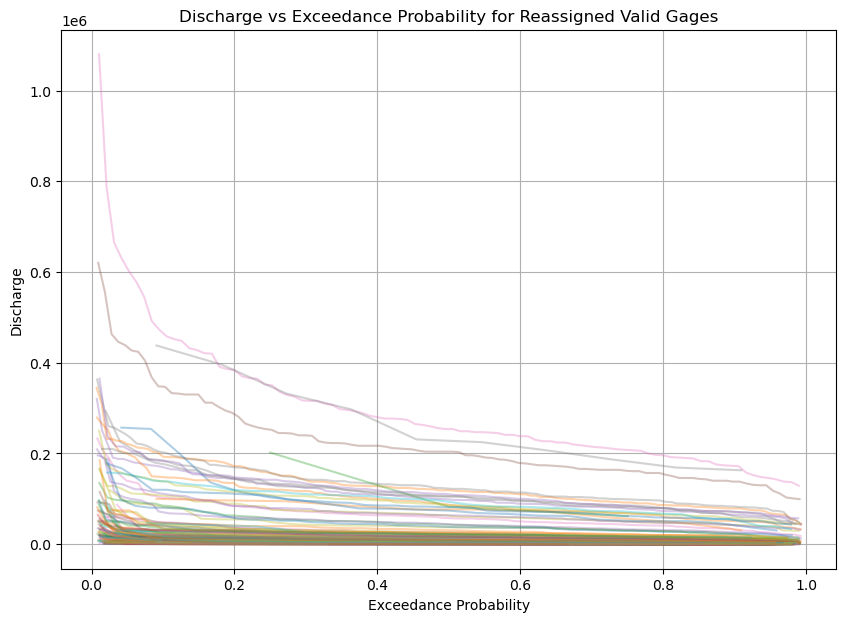

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for site_no, group_df in flood_analysis_valid.groupby("site_no"):
    plt.plot(
        group_df["exceedance_probability"],
        group_df["peak_va"],
        alpha=0.35
    )

plt.xlabel("Exceedance Probability")
plt.ylabel("Discharge")
plt.title("Discharge vs Exceedance Probability for Reassigned Valid Gages")
plt.grid(True)

plt.show()

In [27]:
peak_data_valid_near["peak_va"].describe()

count    9.297000e+03
mean     2.762917e+04
std      5.518940e+04
min      2.500000e+00
25%      2.270000e+03
50%      6.480000e+03
75%      2.330000e+04
max      1.080000e+06
Name: peak_va, dtype: float64

In [28]:
feature_class = "PA_substations_statewide_clean_2272"
fields = ["site_no_1"]

site_list = []

with arcpy.da.SearchCursor(feature_class, fields) as cursor:
    for row in cursor:
        site_no = row[0]
        if site_no is not None and str(site_no).strip() != "":
            site_list.append(str(site_no).strip())

# Convert to DataFrame for easy counting
site_df = pd.DataFrame({"site_no": site_list})

# Count substations per gage
substation_counts = (
    site_df["site_no"]
    .value_counts()
    .reset_index()
)

substation_counts.columns = ["site_no", "n_substations"]

print(substation_counts.head(10))
print("\nTotal gages:", len(substation_counts))

    site_no  n_substations
0  03075070             68
1  04213200             60
2  03041000             44
3  01614140             43
4  03104500             31
5  01538510             31
6  01573560             29
7  01471500             27
8  01573825             26
9  01533800             26

Total gages: 209


In [29]:
print(substation_counts["n_substations"].describe())

count    209.000000
mean      11.162679
std        9.376338
min        1.000000
25%        4.000000
50%        9.000000
75%       16.000000
max       68.000000
Name: n_substations, dtype: float64


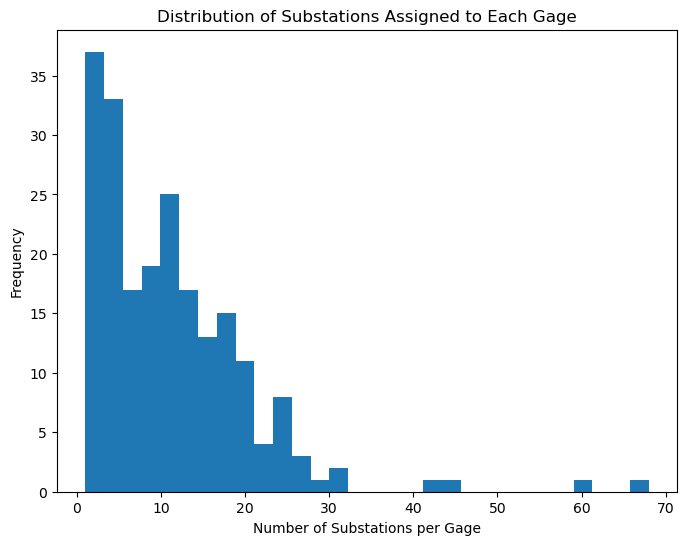

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.hist(substation_counts["n_substations"], bins=30)

plt.xlabel("Number of Substations per Gage")
plt.ylabel("Frequency")
plt.title("Distribution of Substations Assigned to Each Gage")

plt.show()

In [1]:
import arcpy
import pandas as pd

feature_class = "PA_substations_statewide_clean_2272"
fields = ["site_no_1", "station_nm_1", "NEAR_DIST"]

distance_rows = []

with arcpy.da.SearchCursor(feature_class, fields) as cursor:
    for row in cursor:
        site_no = row[0]
        station_nm = row[1]
        near_dist = row[2]
        
        if site_no is not None and near_dist is not None and near_dist != -1:
            distance_rows.append({
                "site_no": str(site_no).strip(),
                "station_nm": station_nm,
                "near_dist_ft": near_dist
            })

distance_df = pd.DataFrame(distance_rows)

print("Rows with valid distance:", len(distance_df))
print(distance_df["near_dist_ft"].describe())

distance_df.head()

Rows with valid distance: 2333
count      2333.000000
mean      30314.745185
std       25143.374865
min         133.882410
25%       11912.472300
50%       23442.629173
75%       42561.307731
max      157487.348011
Name: near_dist_ft, dtype: float64


,site_no,station_nm,near_dist_ft
0,01573825,"West Conewago Creek at East Berlin, PA",63871.591754
1,01573825,"West Conewago Creek at East Berlin, PA",76751.889348
2,01573825,"West Conewago Creek at East Berlin, PA",39539.017938
3,01573825,"West Conewago Creek at East Berlin, PA",55733.250490
4,01573825,"West Conewago Creek at East Berlin, PA",56407.828364


In [2]:
feature_class = "PA_substations_statewide_clean_2272"
fields = ["osm_uid", "name", "site_no_1", "station_nm_1", "NEAR_DIST"]

distance_rows = []

with arcpy.da.SearchCursor(feature_class, fields) as cursor:
    for row in cursor:
        substation_id = row[0]
        substation_name = row[1]
        gage_site_no = row[2]
        gage_station_nm = row[3]
        near_dist = row[4]

        if gage_site_no is not None and near_dist is not None and near_dist != -1:
            distance_rows.append({
                "substation_id": substation_id,
                "substation_name": substation_name,
                "gage_site_no": str(gage_site_no).strip(),
                "gage_station_nm": gage_station_nm,
                "near_dist_ft": near_dist
            })

## Gaging Substation Distance

In [3]:
import arcpy

input_fc = "PA_substations_statewide_clean_2272"
output_fc = "substation_to_gage_lines"

# Create output feature class
arcpy.management.CreateFeatureclass(
    out_path=arcpy.env.workspace,
    out_name=output_fc,
    geometry_type="POLYLINE",
    spatial_reference=input_fc
)

# Add useful fields
arcpy.management.AddField(output_fc, "substation_id", "TEXT")
arcpy.management.AddField(output_fc, "gage_id", "TEXT")
arcpy.management.AddField(output_fc, "distance_ft", "DOUBLE")

# Insert cursor
insert_fields = ["SHAPE@", "substation_id", "gage_id", "distance_ft"]
search_fields = ["SHAPE@XY", "NEAR_X", "NEAR_Y", "osm_uid", "site_no_1", "NEAR_DIST"]

with arcpy.da.InsertCursor(output_fc, insert_fields) as icursor:
    with arcpy.da.SearchCursor(input_fc, search_fields) as scursor:
        for row in scursor:
            sub_x, sub_y = row[0]
            gage_x = row[1]
            gage_y = row[2]
            substation_id = row[3]
            gage_id = row[4]
            dist = row[5]

            if gage_id is not None and gage_x is not None and gage_y is not None:
                line = arcpy.Polyline(
                    arcpy.Array([
                        arcpy.Point(sub_x, sub_y),
                        arcpy.Point(gage_x, gage_y)
                    ])
                )

                icursor.insertRow([line, substation_id, gage_id, dist])

print("Line feature class created.")

Line feature class created.


In [ ]:
import arcpy

input_fc = "PA_substations_statewide_clean_2272"
output_fc = "substation_to_valid_gage_lines"

# Delete old version if it exists
if arcpy.Exists(output_fc):
    arcpy.management.Delete(output_fc)

# Create output line feature class
arcpy.management.CreateFeatureclass(
    out_path=arcpy.env.workspace,
    out_name=output_fc,
    geometry_type="POLYLINE",
    spatial_reference=input_fc
)

# Add fields
arcpy.management.AddField(output_fc, "substation_id", "TEXT")
arcpy.management.AddField(output_fc, "substation_nm", "TEXT")
arcpy.management.AddField(output_fc, "gage_site_no", "TEXT")
arcpy.management.AddField(output_fc, "gage_station", "TEXT")
arcpy.management.AddField(output_fc, "distance_ft", "DOUBLE")

insert_fields = [
    "SHAPE@",
    "substation_id",
    "substation_nm",
    "gage_site_no",
    "gage_station",
    "distance_ft"
]

search_fields = [
    "SHAPE@XY",
    "NEAR_X",
    "NEAR_Y",
    "osm_uid",
    "name",
    "site_no_1",
    "station_nm_1",
    "NEAR_DIST"
]

with arcpy.da.InsertCursor(output_fc, insert_fields) as icursor:
    with arcpy.da.SearchCursor(input_fc, search_fields) as scursor:
        for row in scursor:
            sub_xy = row[0]
            near_x = row[1]
            near_y = row[2]
            substation_id = row[3]
            substation_nm = row[4]
            gage_site_no = row[5]
            gage_station = row[6]
            near_dist = row[7]

            if (
                sub_xy is not None and
                near_x is not None and
                near_y is not None and
                gage_site_no is not None
            ):
                sub_x, sub_y = sub_xy

                line = arcpy.Polyline(
                    arcpy.Array([
                        arcpy.Point(sub_x, sub_y),
                        arcpy.Point(near_x, near_y)
                    ]),
                    arcpy.Describe(input_fc).spatialReference
                )

                icursor.insertRow([
                    line,
                    str(substation_id) if substation_id is not None else None,
                    substation_nm,
                    str(gage_site_no),
                    gage_station,
                    near_dist
                ])

print("Created line layer:", output_fc)